# How well do jobs and skills pay for Data Analysts?

#### Methodology
1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Analysts
3. Visualize for highest paying skills and most demanded skills

In [ ]:

import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

Unfortunately, data from countries other than the USA does not include information on offered salaries, so we will use only the data from the USA.

Filter our data to only include salary values from the United States. Remove
 Na values

In [13]:

df_US = df[(df['job_country'] == 'United States')].dropna(subset=['salary_year_avg'])





Create a list of the main job_titles in our dataset and filter our dataframe to only contain these job titles.

In [14]:
job_titles = df_US['job_title_short'].value_counts().index[:6].tolist()

df_top_6 = df_US[df_US['job_title_short'].isin(job_titles)]

job_order =  df_top_6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending = False ).index
job_order

Index(['Senior Data Scientist', 'Senior Data Engineer', 'Data Scientist',
       'Data Engineer', 'Senior Data Analyst', 'Data Analyst'],
      dtype='str', name='job_title_short')

## Plot Salary Distributions

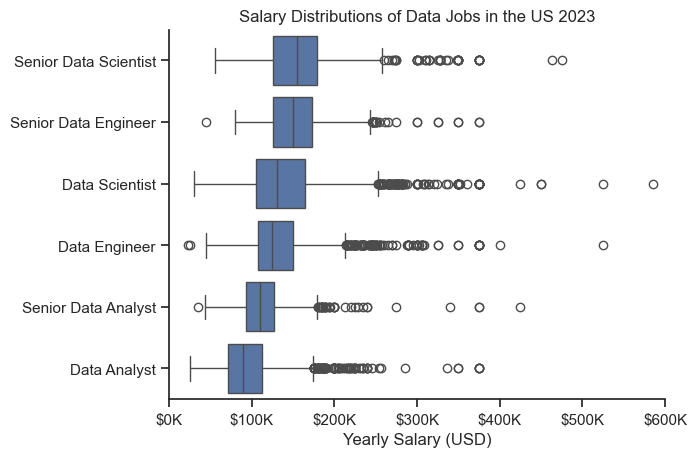

In [15]:
sns.boxplot(
    data = df_top_6, 
    x = 'salary_year_avg',
    y = 'job_title_short',
    orient = 'h',
    order = job_order,
    )
sns.set_theme(style = 'ticks')
sns.despine()

plt.title('Salary Distributions of Data Jobs in the US 2023')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000) 
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.show()

## Investigate Median Salary Vs Skill for Data Analysts

Filters the original dataset to only get rows where the job title is 'Data Analyst' and the country is 'United States', to create a new DataFrame `df_DA_US`. Drop NaN values from the 'salary_year_avg' column. Then it uses the `explode` method on the `job_skills` column to create a new row in the DataFrame for each skill associated with a job. Finally, it displays the first five entries of the `salary_year_avg` and `job_skills` columns.

In [16]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].dropna(subset=['salary_year_avg'])
df_DA_US =  df_DA_US.explode(column= 'job_skills')
df_DA_US[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


## Determine The Highest Paid Skills and Most Demanded Skills

Gets the top ten highest-paying skills for Data Analysts by calculating the median salary for each skill listed in the `df_DA_US`. It groups the data by job skills, computes the median salary, sorts these values in descending order by median, and then selects the top 10. This is then formatted into a new DataFrame (`df_DA_top_pay`) 

In [17]:
df_DA_top_pay = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['median', 'count']).sort_values(by = 'median',ascending = False).reset_index().head(10)

df_DA_top_pay

,job_skills,median,count
0,dplyr,196250.0,2
1,bitbucket,189000.0,3
2,gitlab,186000.0,3
3,solidity,179000.0,1
4,hugging face,175000.0,1
5,couchbase,160515.0,1
6,ansible,159640.0,1
7,mxnet,149000.0,2
8,cassandra,148250.0,6
9,vmware,147500.0,1


Calculates the count and median salary for each skill in `df_DA_US`. It groups the data by `job_skills`, aggregates it to find the count and median salary for each skill, and then sorts the results by count in descending order by count. It re-sorts this subset by median salary in descending order.

In [18]:
df_DA_skills = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)

df_DA_skills

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


Creates two horizontal bar charts: 
1. Displays the highest paid skills 
2. Shows the most in demand skills 

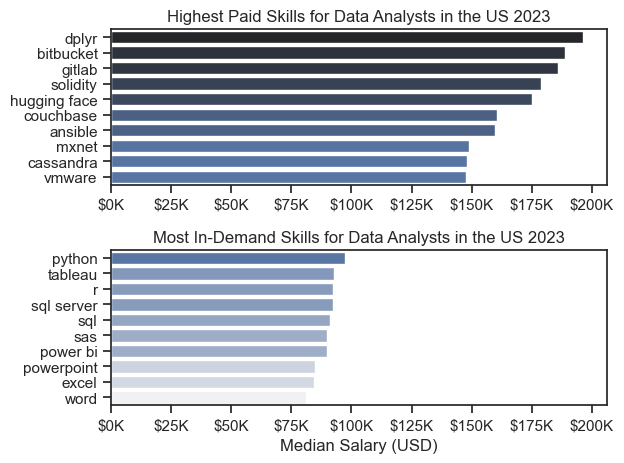

In [19]:
fix, ax = plt.subplots(2,1)

sns.barplot(
    data=df_DA_top_pay, 
    x='median', 
    y= df_DA_top_pay['job_skills'], 
    hue='median', 
    orient = 'h',
    ax=ax[0], 
    palette='dark:b_r')
ax[0].legend().remove()
ax[0].set_title('Highest Paid Skills for Data Analysts in the US 2023')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


sns.barplot(
    data=df_DA_skills, 
    x='median', 
    y=df_DA_skills.index, 
    hue='median', 
    ax=ax[1], 
    palette='light:b')
ax[1].legend().remove()
ax[1].set_title('Most In-Demand Skills for Data Analysts in the US 2023')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())  # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.set_theme(style='ticks')
plt.tight_layout()
plt.show()